In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

np.random.seed(42)
random.seed(42)

In [2]:
n_users = 500
n_days = 90

users = [f"user_{i}" for i in range(n_users)]
divisions = ["Finance", "HR", "Engineering", "Sales", "Marketing", "Operations"]

data = []

start_date = datetime(2025, 1, 1)

for user in users:
    division = random.choice(divisions)
    engagement_level = np.random.beta(2, 5)  # skewed low/high users

    for day in range(n_days):
        if np.random.rand() < engagement_level:
            sessions = np.random.poisson(2) + 1
            tokens_used = int(np.random.normal(1500, 500))
            tasks_completed = np.random.binomial(sessions, 0.7)

            data.append([
                user,
                division,
                start_date + timedelta(days=day),
                sessions,
                max(tokens_used, 100),
                tasks_completed
            ])

df = pd.DataFrame(data, columns=[
    "user_id",
    "division",
    "date",
    "sessions",
    "tokens_used",
    "tasks_completed"
])

df.head()

,user_id,division,date,sessions,tokens_used,tasks_completed
0,user_0,Operations,2025-01-01,2,1639,1
1,user_0,Operations,2025-01-02,4,2005,4
2,user_0,Operations,2025-01-03,3,993,3
3,user_0,Operations,2025-01-07,3,1657,2
4,user_0,Operations,2025-01-08,1,1199,1


In [3]:
heart_df = df.copy()

# Adoption: active users
adoption = heart_df.groupby("division")["user_id"].nunique().reset_index()
adoption.columns = ["division", "active_users"]

# Engagement: avg sessions
engagement = heart_df.groupby("division")["sessions"].mean().reset_index()
engagement.columns = ["division", "avg_sessions"]

# Retention: repeat users
repeat_users = heart_df.groupby("user_id").size()
retention_rate = (repeat_users[repeat_users > 5].count() / n_users)

# Task Success Rate
task_success = heart_df.groupby("division").apply(
    lambda x: x["tasks_completed"].sum() / x["sessions"].sum()
).reset_index()

task_success.columns = ["division", "task_success_rate"]

# Token usage
tokens = heart_df.groupby("division")["tokens_used"].sum().reset_index()
tokens.columns = ["division", "total_tokens"]

heart_metrics = adoption.merge(engagement, on="division") \
                        .merge(task_success, on="division") \
                        .merge(tokens, on="division")

heart_metrics

/tmp/ipykernel_3998/2972192427.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  task_success = heart_df.groupby("division").apply(


,division,active_users,avg_sessions,task_success_rate,total_tokens
0,Engineering,75,3.015668,0.703087,3292757
1,Finance,92,2.974229,0.698011,3534521
2,HR,93,2.983713,0.704421,3712203
3,Marketing,83,3.013360,0.696388,3020135
4,Operations,88,3.013142,0.706556,3685960
5,Sales,68,3.003537,0.695828,2967913


In [4]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

metrics_scaled = heart_metrics.copy()
metrics_scaled[["active_users","avg_sessions","task_success_rate","total_tokens"]] = scaler.fit_transform(
    metrics_scaled[["active_users","avg_sessions","task_success_rate","total_tokens"]]
)

metrics_scaled["ai_maturity_score"] = (
    0.3 * metrics_scaled["active_users"] +
    0.3 * metrics_scaled["avg_sessions"] +
    0.2 * metrics_scaled["task_success_rate"] +
    0.2 * metrics_scaled["total_tokens"]
)

metrics_scaled.sort_values("ai_maturity_score", ascending=False)

,division,active_users,avg_sessions,task_success_rate,total_tokens,ai_maturity_score
4,Operations,0.80,0.939031,1.000000,0.964741,0.914657
2,HR,1.00,0.228874,0.801044,1.000000,0.728871
0,Engineering,0.28,1.000000,0.676642,0.436448,0.606618
3,Marketing,0.60,0.944292,0.052180,0.070164,0.487756
1,Finance,0.96,0.000000,0.203544,0.761273,0.480963
5,Sales,0.00,0.707256,0.000000,0.000000,0.212177


In [5]:
user_activity = df.groupby("user_id")["sessions"].sum().reset_index()

threshold = user_activity["sessions"].quantile(0.8)

user_activity["segment"] = np.where(
    user_activity["sessions"] >= threshold,
    "Power User",
    "Normal User"
)

user_activity["segment"].value_counts()

,count
segment,
Normal User,399
Power User,100


In [6]:
df.to_csv("ai_usage_logs.csv", index=False)
heart_metrics.to_csv("heart_metrics.csv", index=False)
user_activity.to_csv("user_segments.csv", index=False)

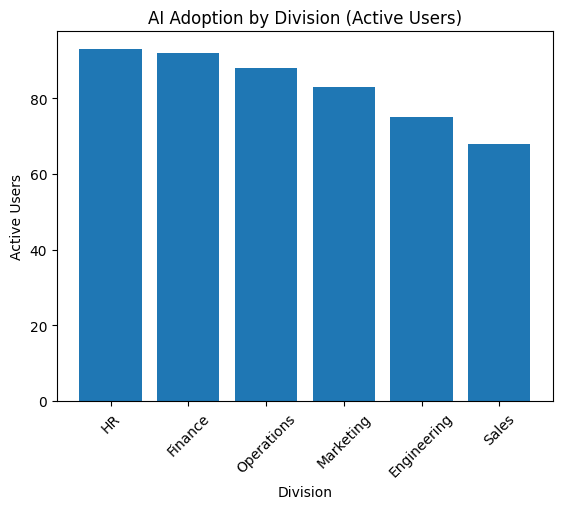

In [7]:
import matplotlib.pyplot as plt

adoption_plot = heart_metrics.sort_values("active_users", ascending=False)

plt.figure()
plt.bar(adoption_plot["division"], adoption_plot["active_users"])
plt.title("AI Adoption by Division (Active Users)")
plt.xlabel("Division")
plt.ylabel("Active Users")
plt.xticks(rotation=45)
plt.show()

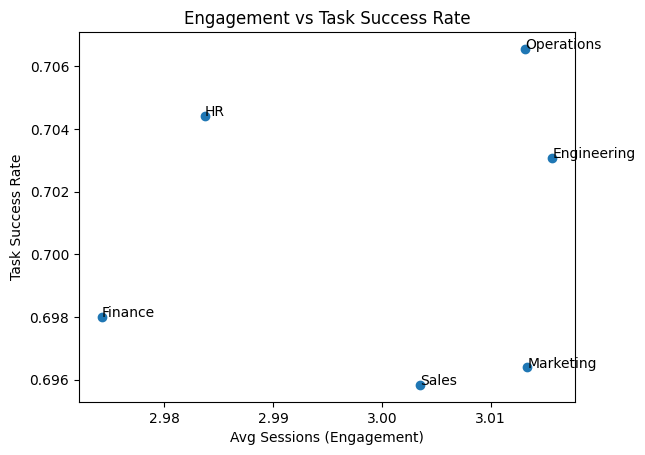

In [8]:
plt.figure()
plt.scatter(
    heart_metrics["avg_sessions"],
    heart_metrics["task_success_rate"]
)

for i, txt in enumerate(heart_metrics["division"]):
    plt.annotate(txt, (heart_metrics["avg_sessions"][i], heart_metrics["task_success_rate"][i]))

plt.title("Engagement vs Task Success Rate")
plt.xlabel("Avg Sessions (Engagement)")
plt.ylabel("Task Success Rate")
plt.show()

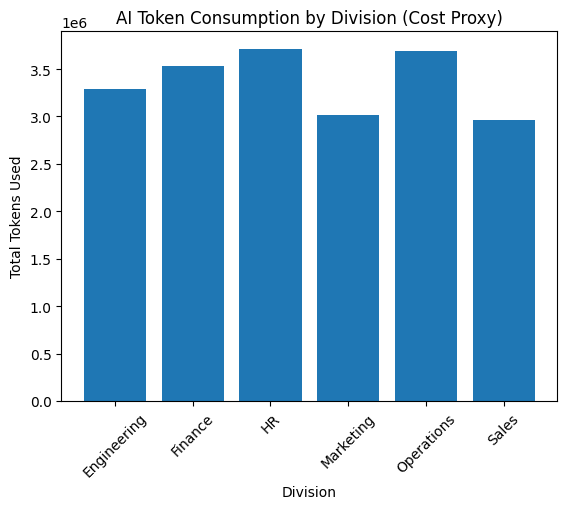

In [9]:
plt.figure()
plt.bar(heart_metrics["division"], heart_metrics["total_tokens"])
plt.title("AI Token Consumption by Division (Cost Proxy)")
plt.xlabel("Division")
plt.ylabel("Total Tokens Used")
plt.xticks(rotation=45)
plt.show()

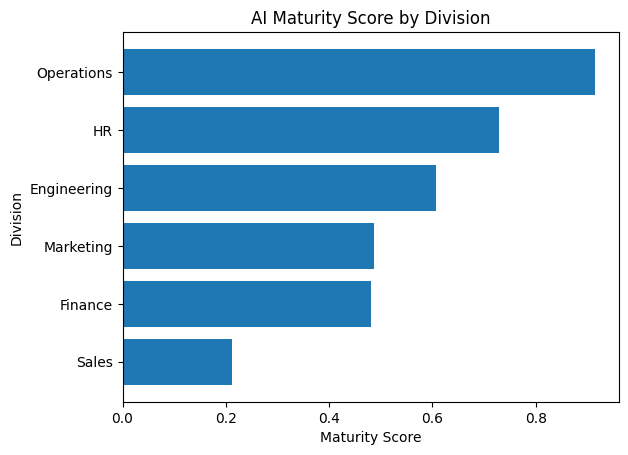

In [10]:
sorted_maturity = metrics_scaled.sort_values("ai_maturity_score", ascending=True)

plt.figure()
plt.barh(sorted_maturity["division"], sorted_maturity["ai_maturity_score"])
plt.title("AI Maturity Score by Division")
plt.xlabel("Maturity Score")
plt.ylabel("Division")
plt.show()

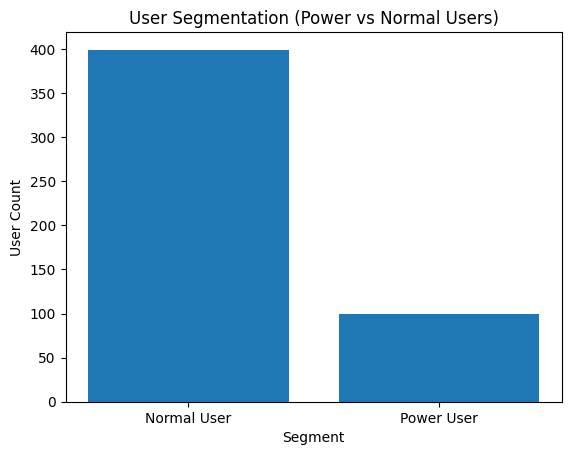

In [11]:
segment_counts = user_activity["segment"].value_counts()

plt.figure()
plt.bar(segment_counts.index, segment_counts.values)
plt.title("User Segmentation (Power vs Normal Users)")
plt.xlabel("Segment")
plt.ylabel("User Count")
plt.show()